<a href="https://colab.research.google.com/github/rithya999/Elevate_labs_finalproject/blob/main/Airbnb_Price_Prediction_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import files
uploaded = files.upload()

Saving AB_NYC_2019.csv to AB_NYC_2019.csv


In [17]:
import zipfile

with zipfile.ZipFile("airbnb-listings.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()

import os
print(os.listdir())

['.config', 'airbnb-listings.csv.zip', 'airbnb-listings.csv (1).zip', 'sample_data']


In [2]:
import zipfile

with zipfile.ZipFile("/content/airbnb-listings.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Unzipped successfully!")

Unzipped successfully!


In [16]:
import pandas as pd

df = pd.read_csv("AB_NYC_2019.csv")
df.head()



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [26]:
df.shape

(48895, 16)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [28]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [27]:
df['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


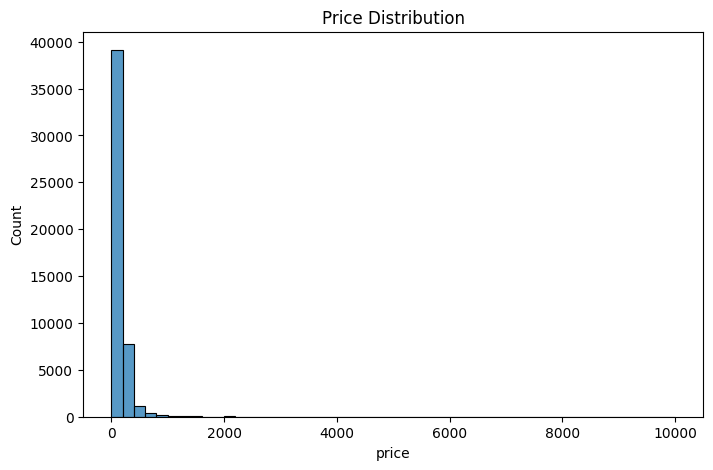

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

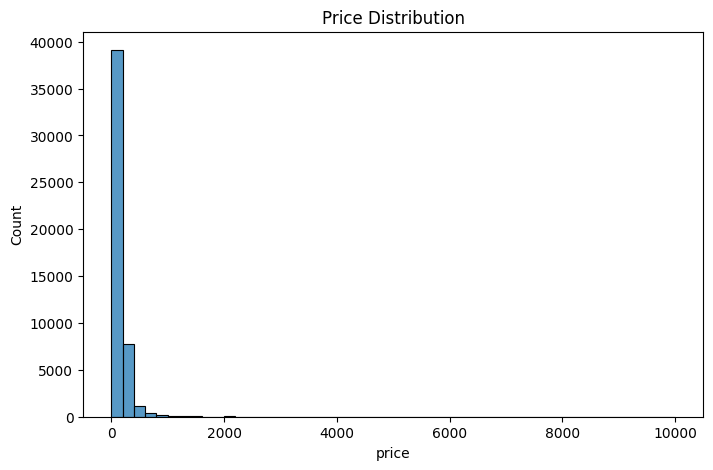

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

In [33]:
df = df[df['price'] > 0]
df = df[df['price'] < 1000]

df['price'].describe()

,price
count,48586.000000
mean,140.269049
std,112.899316
min,10.000000
25%,69.000000
50%,105.000000
75%,175.000000
max,999.000000


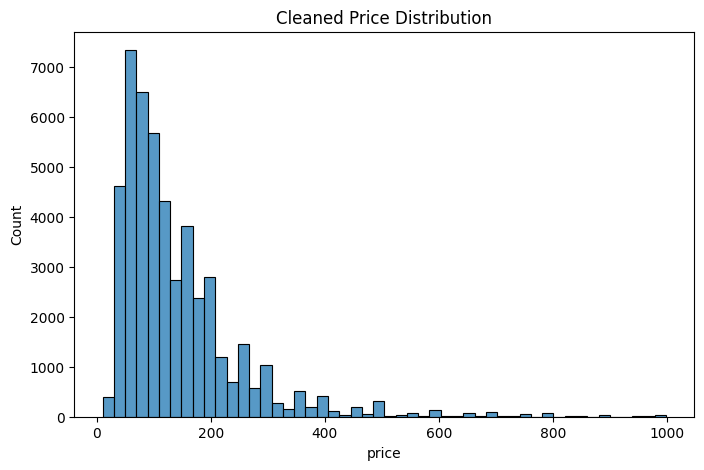

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Cleaned Price Distribution")
plt.show()

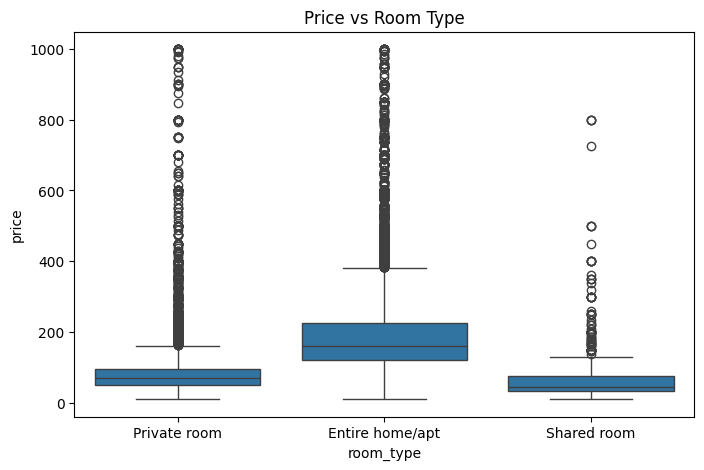

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Price vs Room Type")
plt.show()

In [36]:
df.groupby('room_type')['price'].mean()

,price
room_type,
Entire home/apt,192.948140
Private room,84.581777
Shared room,66.116118


In [37]:
df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

,price
neighbourhood_group,
Manhattan,177.375017
Brooklyn,117.288246
Staten Island,96.148649
Queens,94.528038
Bronx,84.521140


In [38]:
df.groupby(['neighbourhood_group', 'room_type'])['price'].mean().sort_values(ascending=False)

neighbourhood_group  room_type      
Manhattan            Entire home/apt    222.480983
Brooklyn             Entire home/apt    167.646372
Queens               Entire home/apt    141.172414
Staten Island        Entire home/apt    134.953757
Bronx                Entire home/apt    125.198413
Manhattan            Private room       108.998240
                     Shared room         87.075157
Brooklyn             Private room        72.609479
Queens               Private room        68.244214
Bronx                Private room        63.147692
Staten Island        Private room        62.292553
Bronx                Shared room         59.800000
Staten Island        Shared room         57.444444
Brooklyn             Shared room         50.773723
Queens               Shared room         49.312821
Name: price, dtype: float64

In [39]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [40]:
df = df.drop(['id', 'name', 'host_name', 'last_review'], axis=1)

In [41]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [42]:
df.isnull().sum()

,0
host_id,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0


In [43]:
X = df.drop('price', axis=1)
y = df['price']

# Convert categorical columns into dummy variables
X = pd.get_dummies(X, drop_first=True)

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 53.36314897669013
RMSE: 90.32398597306421
R2 Score: 0.36448728479680137


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 53.36314897669013
RMSE: 90.32398597306421
R2 Score: 0.36448728479680137


In [49]:
feature_importance = pd.Series(model.coef_, index=X.columns)
feature_importance.sort_values(ascending=False)

,0
neighbourhood_Fort Wadsworth,646.454795
neighbourhood_Woodrow,523.674198
neighbourhood_Riverdale,143.411661
neighbourhood_Breezy Point,113.350061
neighbourhood_Far Rockaway,100.843230
...,...
neighbourhood_group_Staten Island,-110.216114
neighbourhood_Rossville,-110.887759
room_type_Shared room,-116.055937
neighbourhood_Howland Hook,-116.699573


In [50]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.36448728479680137


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.45784360270262314


In [52]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

room_type_Private room            0.205473
longitude                         0.166305
latitude                          0.125158
host_id                           0.098709
availability_365                  0.094694
reviews_per_month                 0.055043
minimum_nights                    0.052993
number_of_reviews                 0.046345
calculated_host_listings_count    0.037453
room_type_Shared room             0.023691
dtype: float64


In [53]:
sample = X_test.iloc[[0]]
rf.predict(sample)

array([64.66])

In [54]:
y_test.iloc[0]

np.int64(65)

In [10]:
!pip install catboost

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor
import numpy as np

In [19]:
X = df.drop("price", axis=1)
y = df["price"]

X = pd.get_dummies(X)

In [12]:
test_splits = [0.2, 0.3, 0.4]

In [10]:
from sklearn.model_selection import train_test_split

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# Load data
df = pd.read_csv("AB_NYC_2019.csv")

# Prepare data
X = df.drop("price", axis=1)
y = df["price"]

X = pd.get_dummies(X)
X = X.fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = CatBoostRegressor(
    iterations=50,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 74.25092124719147
RMSE: 201.23522148074522
R2: 0.0846015511862146


In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [7]:
!pip install xgboost

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import numpy as np

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)
}

for split in [0.2,0.3,0.4]:
    print("\nTEST SIZE:", split)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print(name, "RMSE:", rmse, "R2:", r2)

In [1]:
from sklearn.metrics import mean_absolute_error

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)
}

for split in [0.2, 0.3, 0.4]:
    print("\nTEST SIZE:", split)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)

        print(name, "MAE:", mae)

In [ ]:
import pandas as pd
import numpy as np

results = []

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)
}

for split in [0.2, 0.3, 0.4]:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": name,
            "Test Split": split,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

results_df = pd.DataFrame(results)

results_df